# Creating CNNs in PyTorch

In this notebook, we will create and train a CNN on the `CIFAR10` image dataset. The `CIFAR10` dataset is a collection `60,000` images that have been sampled from an even larger dataset of 60 million images scrapped by a web crawler and curated by Alex Krizhevsky. As the name suggests, `CIFAR10` has ten target classes consisting of various animals (bird, cat, dog, etc.) and modes of transport (ship, truck, plane, etc.). Let us start by importing the required modules,

In [56]:
# PyTorch imports,
import torch 
import torchvision
from torch.optim import Adam 
from torchinfo import summary
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torch.nn import Conv2d, AvgPool2d, Linear, CrossEntropyLoss

# NumPy, Pandas and Matplot,
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from safetensors.torch import load_model, save_model, save_file, load_file
import os
import sys
from datetime import datetime

# Printing versions,
print("System Version:", sys.version)
print("PyTorch version", torch.__version__)
print("TorchVision version", torchvision.__version__)
print("Numpy version", np.__version__)
print("Pandas version", pd.__version__)

System Version: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
PyTorch version 2.6.0+cpu
TorchVision version 0.21.0+cpu
Numpy version 1.26.4
Pandas version 2.2.2


### 1. Loading `CIFAR10`

The `CIFAR10` dataset can easily be loaded with `torchvision`. We apply a transformation to convert the images into tensors while also normalising them. It is extremely important to normalise the images via $(X_i - \mu_k)/ \sigma_k$ for each channel to allow the network to learn.

In [57]:
# Defining transforms,
CIFAR10_MEAN, CIFAR10_STD = (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

# Downloading CIFAR10,
data_train = torchvision.datasets.CIFAR10(root="../datasets/CIFAR10", train=True, download=True, transform=transform)

# Creating a list for the classes,
classes = data_train.classes


Each image has `32x32` pixels with RGB colour. RBG images have three channels, as opposed to gray scale images which only have a single channel. PyTorch uses a channel first scheme while Matplotlib use a channel last scheme. For this reason, we permute the image before visualising it via Matplotlib,

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.2546015..2.300854].


Image shape: torch.Size([3, 32, 32])
Label: 4 (deer)


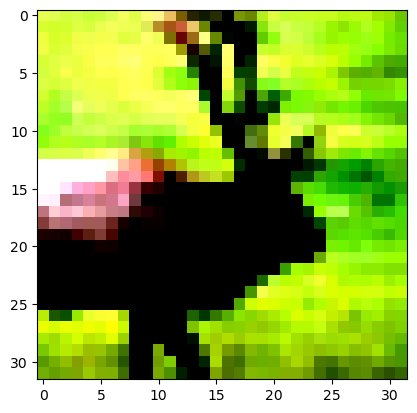

In [58]:
# Extacting image,
idx = 34
img, label = data_train[idx]
print(f"Image shape: {img.shape}")
print(f"Label: {label} ({classes[label]})")

# Plotting,
img = img.permute(1, 2, 0) # <-- Channel-last scheme.
plt.imshow(img)
plt.show()

Now we create the `DataLoader` object for our training images,

In [59]:
# Creating dataloader,
BATCH_SIZE = 32
train_loader = DataLoader(data_train, batch_size=BATCH_SIZE, shuffle=True)

# A batch,
for (X, y) in train_loader:
    print(f"Batch shape: {X.shape}")
    print(f"Target shape: {y.shape}")
    break

Batch shape: torch.Size([32, 3, 32, 32])
Target shape: torch.Size([32])


### 2. Model Creation

For the CNN, we closely replicate LeNet-5. We use `Conv2d` for the convolutional layers since we are working with images (2D tensors excluding channel and batch dimensions). In PyTorch, we usually only specify the `in_channels` (number of input feature maps), `ourput_channels` (number of output feature maps) and the `kernel_size` (tuple or scaler for square kernels). By default, we have `stride=1`, no padding `padding=0` and `dilation=1`. Mean pooling layers are implemented with `AvgPool2d` where only the `kernel_size` has to be specified (`stride=None` and `padding=0` by default). According the orginal LeNet-5 paper, the structure of the network was as follows,

| Layer  | Type         | Maps / Units | Kernel | Stride | Activation  | Parameters |
| :----- | :----------- | :----------- | :----- | :----- | :---------- | :--------- | 
| Input  | Image        | 1 (32x32)    | -      | -      | -           | 0          | 
| C1     | Conv         | 6 (28x28)    | 5x5    | 1      | Scaled Tanh | 156        | 
| S2     | Subsampling  | 6 (14x14)    | 2x2    | 2      | Scaled Tanh | 12         | 
| C3     | Conv         | 16 (10x10)   | 5x5    | 1      | Scaled Tanh | 1,516      | 
| S4     | Subsampling  | 16 (5x5)     | 2x2    | 2      | Scaled Tanh | 32         | 
| C5     | Conv* | 120 (1x1)    | 5x5    | 1      | Scaled Tanh | 48,120     | 
| F6     | Fully Connected   | 84           | -      | -      | Scaled Tanh | 10,164     | 
| Output | RBF          | 10           | -      | -      | Euclidean   | 0          |

Much of the terminology is out of date and not often used in modern deep learning. The pooling layers are referred to as "subsampling" layers. Unlike modern implementation of pooling layers, these subsampling layers had trainable parameters. Another [... go over the difference and legacy layers/loss function]. For our purposes, we we implement a modernised version of LeNet-5,

| Layer  | Type      | Output Maps / Units | Kernel | Stride | Padding | Dilation | Activation | Parameters |
| :----- | :-------- | :----------- | :----- | :----- | :------ | :------- | :--------- | :--------- |
| Input  | Image     | 1 (32x32)    | -      | -      | -       | -        | -          | 0          |
| C1     | Conv2d    | 6 (32x32)    | 5x5    | 1      | 2       | 1        | ReLU      | 456        |
| S2     | AvgPool2d | 6 (16x16)    | 2x2    | 2      | 0       | 1        | -       | 0          |
| C3     | Conv2d    | 16 (12x12)   | 5x5    | 1      | 0       | 1        | ReLU      | 2,416      |
| S4     | AvgPool2d | 16 (6x6)     | 2x2    | 2      | 0       | 1        | -       | 0          |
| C5     | Linear    | 120          | -      | -      | -       | -        | ReLU       | 69,240     |
| F6     | Linear    | 84           | -      | -      | -       | -        | ReLU       | 10,164     |
| Output | Linear    | 10           | -      | -      | -       | -        | None       | 850        |

In total, our network has `83,126` trainable parameters. We replace all hyperbolic tangent activations with the ReLU activation function as it is easier to compute and avoids the vanishing gradient problem. The subsampling layers are replaced with their modern equivalent - average pooling layers. Moreover, we do not include a softmax activation for the output layer and instead work with logits which are more numerically stable when performing backpropropagation.

In [60]:
class Model(torch.nn.Module):

    def __init__(self):
        super(Model, self).__init__()

        # Definining the layers,
        self.conv1 = Conv2d(in_channels=3, out_channels=6, kernel_size=5, padding=2)
        self.pool1 = AvgPool2d(kernel_size=2, stride=2)
        self.conv2 = Conv2d(in_channels=6, out_channels=16, kernel_size=5)
        self.pool2 = AvgPool2d(kernel_size=2, stride=2)
        self.fc1 = Linear(in_features=16*6*6, out_features=120)
        self.fc2 = Linear(in_features=120, out_features=84)
        self.fc3 = Linear(in_features=84, out_features=10)

    def forward(self, x):
        """Forward pass of the network."""

        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = x.view(-1, 16 * 6 * 6) # <-- Flattening tensor.
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))

        return x

To test the foward propagation of our network, we use `torchinfo`,

In [6]:
# Creating the neural network,
model = Model()
summary(model, input_size=(BATCH_SIZE, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [32, 10]                  --
├─Conv2d: 1-1                            [32, 6, 32, 32]           456
├─AvgPool2d: 1-2                         [32, 6, 16, 16]           --
├─Conv2d: 1-3                            [32, 16, 12, 12]          2,416
├─AvgPool2d: 1-4                         [32, 16, 6, 6]            --
├─Linear: 1-5                            [32, 120]                 69,240
├─Linear: 1-6                            [32, 84]                  10,164
├─Linear: 1-7                            [32, 10]                  850
Total params: 83,126
Trainable params: 83,126
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 28.64
Input size (MB): 0.39
Forward/backward pass size (MB): 2.22
Params size (MB): 0.33
Estimated Total Size (MB): 2.94

### 3. Model Training



In [9]:
# Hyperparameters,
n_epochs = 25
lr = 1e-3

# Setting the model to training mode,
model.train()

# Enabling CUDA (if possible),
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Training on: {device}")

# Creating the optimiser,
optimiser = Adam(model.parameters(), lr=lr)

# Specifying the loss function,
loss_fn = torch.nn.CrossEntropyLoss()

"""TRAINING LOOP"""
epoch_losses = []
for epoch in range(1, n_epochs+1):
    running_loss = 0.0

    # Batch loop,
    for (X, y) in train_loader:

        # Clear gradients,
        optimiser.zero_grad()

        # Moving tensors to training device,
        X, y = X.to(device), y.to(device)

        # Forward pass,
        y_pred = model(X)
        loss = loss_fn(y_pred, y)

        # Backward pass,
        loss.backward()
        optimiser.step()

        # Tracking loss,
        running_loss += loss.item()

    # Printing,
    epoch_loss = running_loss / len(train_loader)
    print(f"Epoch: {epoch}, Avg Loss: {epoch_loss}")
    epoch_losses.append(epoch_loss)

Training on: cpu
Epoch: 1, Avg Loss: 1.2341652144549828
Epoch: 2, Avg Loss: 1.2033226422903558
Epoch: 3, Avg Loss: 1.1763927582281946
Epoch: 4, Avg Loss: 1.155089755795815
Epoch: 5, Avg Loss: 1.1363703937997287
Epoch: 6, Avg Loss: 1.1151581594216389
Epoch: 7, Avg Loss: 1.0964986945640103
Epoch: 8, Avg Loss: 1.0804932118415527
Epoch: 9, Avg Loss: 1.0634048266130156
Epoch: 10, Avg Loss: 1.0468921851478779
Epoch: 11, Avg Loss: 1.0342864214763836
Epoch: 12, Avg Loss: 1.025217914783413
Epoch: 13, Avg Loss: 1.017480888945585
Epoch: 14, Avg Loss: 1.0106472167271647
Epoch: 15, Avg Loss: 0.9972235786556358
Epoch: 16, Avg Loss: 0.9833676130513845
Epoch: 17, Avg Loss: 0.9779989958877222
Epoch: 18, Avg Loss: 0.9816404745049455
Epoch: 19, Avg Loss: 0.9712882534441701
Epoch: 20, Avg Loss: 0.9600098509477334
Epoch: 21, Avg Loss: 0.9625306540167035
Epoch: 22, Avg Loss: 0.9589039241550675
Epoch: 23, Avg Loss: 0.9472308250588632
Epoch: 24, Avg Loss: 0.9461257872258099
Epoch: 25, Avg Loss: 0.940565369789

Visualising the average loss across epochs,

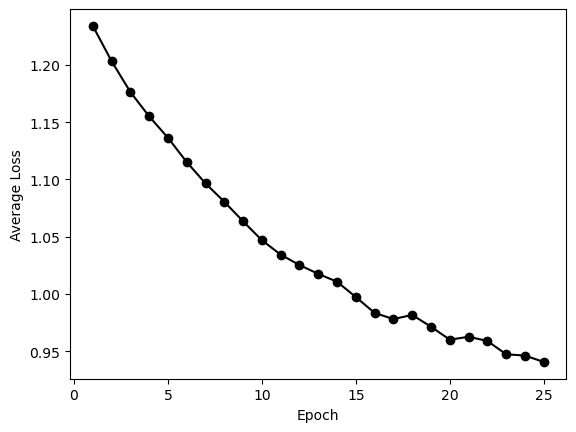

In [11]:
# Plotting,
epochs = np.arange(start=1, stop=n_epochs+1, step=1)
plt.plot(epochs, epoch_losses, marker="o", color="black")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.show()

We save the model and its associated optimiser for deployment or future training. By default, `PyTorch` create `.pt` via `torch.save`, which serialises the model and optimiser state using `pickle` under the hood. However, `.pt` files are susceptible to _"pickle injection"_ attacks, which inject malicious lines of code into the serialised object. These attacks take advantage of the fact that when `.pt` is deserialised, the reconstructed Python code is directly run at the same time. For this reason, the industry standard is to use `safetenors` for added security. In `safetenors`, the model parameters and optimiser state are stored as tensors, not instructions.
For completion, using `PyTorch`,

In [ ]:
# Creating timestamp,
timestamp = datetime.now().strftime("%Y%m%d-%H%M")

# Saving model and optimiser state,
os.makedirs("./models", exist_ok=True)
torch.save(model.state_dict(), f"./models/model-{timestamp}.pt")
torch.save(optimiser.state_dict(), f"./models/optimiser-{timestamp}.pt")
print(f"Saved Checkpoints at: {timestamp}")

Saved Checkpoints at: 20260321-1631


To load the model, we must initialise the network class (with exactly the same architecture). `nn.Module` has a `load_state_dict` class that allows us to load the model from its serialised form,

In [38]:
# Specifying timestamp,
checkpoint_timestamp = "20260321-1631"

# Loading the mode,
model = Model()
model.load_state_dict(torch.load(f"./models/model-{checkpoint_timestamp}.pt", weights_only=True))
model.eval()

# OPTIONAL: Load the optimiser state,
optimiser = Adam(model.parameters())
optimiser.load_state_dict(torch.load(f"./models/optimiser-{checkpoint_timestamp}.pt", weights_only=True))

Using `safetensors` we can perform the same task, but in a more secure way. The boilerplate code is as folliows,

In [61]:
# Creating timestamp,
timestamp = datetime.now().strftime("%Y%m%d-%H%M")

# Saving model and optimiser state,
os.makedirs("./models", exist_ok=True)
save_model(model, f"./models/model-{timestamp}.safetensors")
torch.save(optimiser.state_dict(), f"./models/optimiser-{timestamp}.pt")
print(f"Saved Checkpoints at: {timestamp}")

Saved Checkpoints at: 20260322-1531


Notice that `safetensors` was not desgined to save the optimiser state. Now, we load the model,

In [62]:
# Specifitying timestamp
checkpoint_timestamp= "20260322-1457"

# Loading the model,
model = Model()
load_model(model, f"./models/model-{checkpoint_timestamp}.safetensors")
model.eval()

# OPTIONAL: Load the optimiser state,
optimiser = Adam(model.parameters())
optimiser.load_state_dict(torch.load(f"./models/optimiser-{checkpoint_timestamp}.pt", weights_only=True))

### 4. Basic Model Evaluation

### References

GradientBased Learning Applied to Document
Recognition (LeNet-5 paper). LeCun et al. (1998). URL: http://vision.stanford.edu/cs598_spring07/papers/Lecun98.pdf

PyTorch documentation on saving and loading models. URL: https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html